In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed_data.csv")

In [3]:
route_summary = df.groupby(["Origin Factory", "Region"]).agg(
    Avg_Lead_Time = ("Synthetic Lead Time", "mean"),
    Avg_Distance = ("Distance (km)", "mean"),
    Order_Count = ("Order ID", "count"),
    Avg_Gross_Profit = ("Gross Profit", "mean")
).reset_index()

print(route_summary.shape)
route_summary.sort_values("Avg_Lead_Time", ascending= False).head(10)

(20, 6)


,Origin Factory,Region,Avg_Lead_Time,Avg_Distance,Order_Count,Avg_Gross_Profit
19,Wicked Choccy's,Pacific,7.134873,3459.820403,1342,8.992109
0,Lot's O' Nuts,Atlantic,6.956653,3313.213498,1661,9.220728
1,Lot's O' Nuts,Gulf,6.202899,2692.724704,897,9.268027
9,Sugar Shack,Gulf,6.000000,2303.071662,4,5.810000
15,The Other Factory,Pacific,5.968750,2641.296524,32,1.914062
11,Sugar Shack,Pacific,5.666667,2148.974835,3,3.596667
8,Sugar Shack,Atlantic,5.500000,1834.054574,18,3.545000
7,Secret Factory,Pacific,5.444444,2340.994631,63,24.730952
2,Lot's O' Nuts,Interior,5.321726,1915.091691,1321,9.351673
12,The Other Factory,Atlantic,4.631579,1488.465807,38,1.440789


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ["Avg_Lead_Time", "Avg_Distance", "Order_Count", "Avg_Gross_Profit"]
X_cluster = route_summary[cluster_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters= 3, random_state= 42, n_init= 10)
route_summary["Cluster"] = kmeans.fit_predict(X_scaled)

route_summary.sort_values("Avg_Lead_Time", ascending= False)

,Origin Factory,Region,Avg_Lead_Time,Avg_Distance,Order_Count,Avg_Gross_Profit,Cluster
19,Wicked Choccy's,Pacific,7.134873,3459.820403,1342,8.992109,0
0,Lot's O' Nuts,Atlantic,6.956653,3313.213498,1661,9.220728,0
1,Lot's O' Nuts,Gulf,6.202899,2692.724704,897,9.268027,0
9,Sugar Shack,Gulf,6.000000,2303.071662,4,5.810000,2
15,The Other Factory,Pacific,5.968750,2641.296524,32,1.914062,2
11,Sugar Shack,Pacific,5.666667,2148.974835,3,3.596667,2
8,Sugar Shack,Atlantic,5.500000,1834.054574,18,3.545000,2
7,Secret Factory,Pacific,5.444444,2340.994631,63,24.730952,1
2,Lot's O' Nuts,Interior,5.321726,1915.091691,1321,9.351673,0
12,The Other Factory,Atlantic,4.631579,1488.465807,38,1.440789,2


In [5]:
route_summary.groupby("Cluster")[cluster_features].mean()

,Avg_Lead_Time,Avg_Distance,Order_Count,Avg_Gross_Profit
Cluster,,,,
0,6.404038,2845.212574,1305.250,9.208134
1,4.274176,1194.405983,605.000,13.932629
2,4.896338,1662.800887,16.625,2.688921


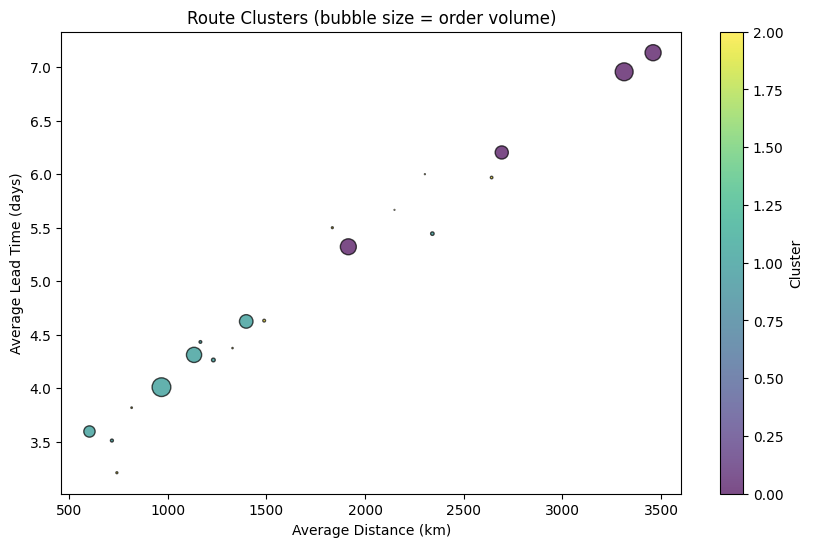

In [6]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(route_summary["Avg_Distance"], route_summary["Avg_Lead_Time"], c= route_summary["Cluster"], s= route_summary["Order_Count"]/10, cmap= "viridis", alpha= 0.7, edgecolors= "black")

plt.title("Route Clusters (bubble size = order volume)")
plt.xlabel("Average Distance (km)")
plt.ylabel("Average Lead Time (days)")
plt.colorbar(scatter, label = "Cluster")
plt.show()

In [ ]:
# route_summary.to_csv("../data/route_clusters.csv", index= False)

Saved
